# Step 1: Mount Google Drive for Saving model for future use.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os
save_dir = '/content/drive/MyDrive/sentiment_project/'
os.makedirs(save_dir, exist_ok=True)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# Step 2: Install & Import All the Tools and Libs

In [ ]:
!pip install -q tensorflow numpy pandas scikit-learn matplotlib seaborn nltk

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout
from tensorflow.keras.utils import plot_model
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from IPython.display import Image
import pickle

nltk.download('stopwords')
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.19.0


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


# Step 3: Loading IMDb Dataset from CSV

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/sentiment_project/IMDB Dataset.csv')  # Change path if needed

print("Shape:", df.shape)
print(df['sentiment'].value_counts())  # Check balance

Shape: (50000, 2)
sentiment
positive    25000
negative    25000
Name: count, dtype: int64


# Step 4: Cleaning the Text (Preprocessing)

In [ ]:
stop_words = set(stopwords.words('english'))

def preprocess_text(text):
    text = text.lower()                          # Lowercase
    text = re.sub(r'<.*?>', '', text)            # HTML tags if present
    text = re.sub(r'[^\w\s]', '', text)          # punctuation
    words = [w for w in text.split() if w not in stop_words]  # stopwords  like "the, is, in" etc..
    return ' '.join(words)

df['cleaned_review'] = df['review'].apply(preprocess_text)
print("Sample cleaned:", df['cleaned_review'][0][:200])

Sample cleaned: one reviewers mentioned watching 1 oz episode youll hooked right exactly happened methe first thing struck oz brutality unflinching scenes violence set right word go trust show faint hearted timid sho


# Step 5: Tokenization and Padding

In [ ]:
num_words = 10000      # Keep only top 10,000 most frequent words
max_length = 200       # Truncate/pad all reviews to 200 words

tokenizer = Tokenizer(num_words=num_words, oov_token='<OOV>')
tokenizer.fit_on_texts(df['cleaned_review'])          # Build vocabulary
sequences = tokenizer.texts_to_sequences(df['cleaned_review'])
padded = pad_sequences(sequences, maxlen=max_length, padding='post', truncating='post')

labels = np.array([1 if s == 'positive' else 0 for s in df['sentiment']])

# Step 6: Split Data into Training & Testing Sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(padded, labels, test_size=0.2, random_state=42)
print("Training samples:", len(X_train))

Training samples: 40000


# Step 7: Build the LSTM Model

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 128)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,411,713 (5.39 MB)

 Trainable params: 1,411,713 (5.39 MB)

 Non-trainable params: 0 (0.00 B)

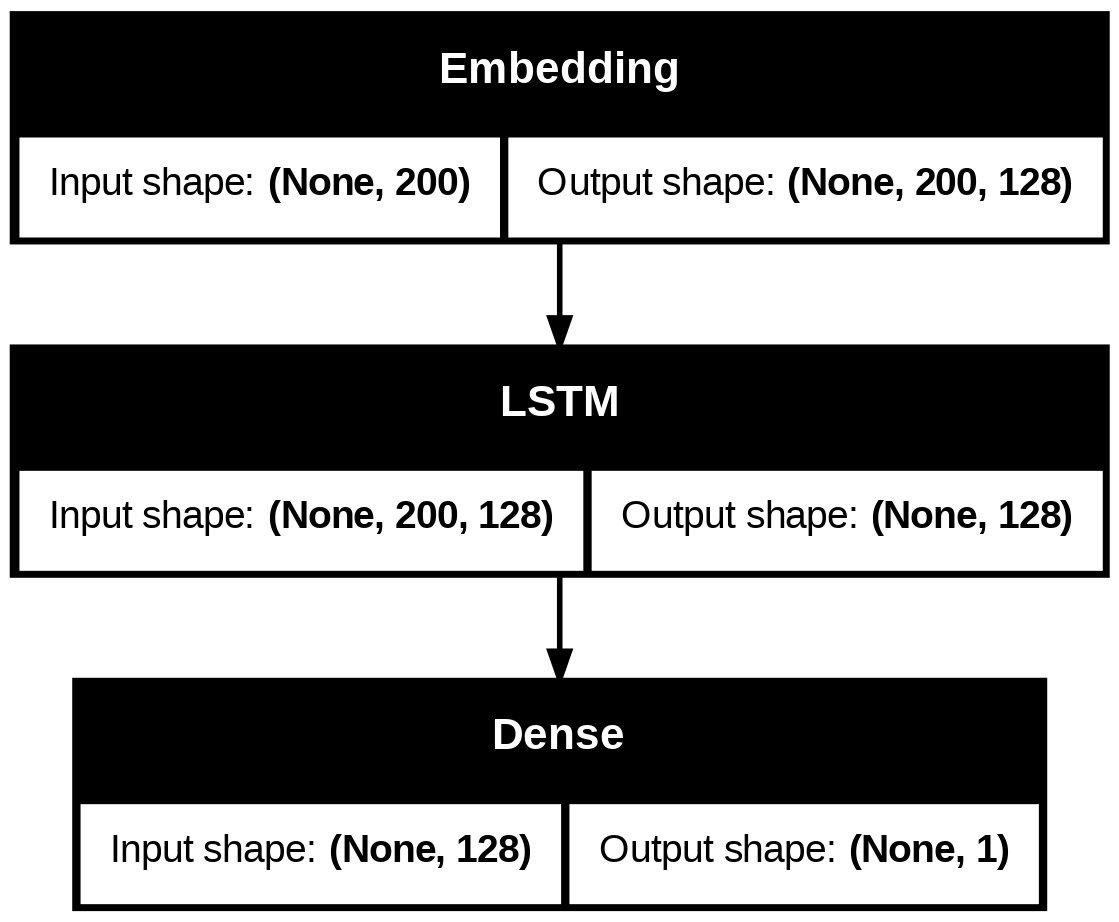

In [ ]:
embedding_dim = 128

model = Sequential([
    Embedding(input_dim=num_words, output_dim=embedding_dim, input_length=max_length),
    LSTM(128, dropout=0.2, recurrent_dropout=0.2),  # LSTM captures sequence dependencies
    Dense(1, activation='sigmoid')                  # Binary output (positive/negative)
])

model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

# Build model
model.build(input_shape=(None, max_length))
model.summary()

# Visualize
plot_model(model, show_shapes=True, to_file='model.png')
Image('model.png')

# Step 8: Train the Model (Or Load a Saved One)

In [ ]:
model_path = os.path.join(save_dir, 'sentiment_model.h5')
tokenizer_path = os.path.join(save_dir, 'tokenizer.pickle')

if os.path.exists(model_path) and os.path.exists(tokenizer_path):
    model = load_model(model_path)
    with open(tokenizer_path, 'rb') as f:
        tokenizer = pickle.load(f)
    print("✓ Loaded saved model & tokenizer")
else:
    print("Training new model...")
    history = model.fit(X_train, y_train,
                        epochs=5,
                        batch_size=64,
                        validation_split=0.2,
                        verbose=1)

    # Save for future use
    model.save(model_path)
    with open(tokenizer_path, 'wb') as f:
        pickle.dump(tokenizer, f, protocol=pickle.HIGHEST_PROTOCOL)
    print("✓ Model & tokenizer saved to Google Drive")

Training new model...
Epoch 1/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 306s 612ms/step - accuracy: 0.5148 - loss: 0.6931 - val_accuracy: 0.5217 - val_loss: 0.6926
Epoch 2/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 311s 591ms/step - accuracy: 0.5452 - loss: 0.6841 - val_accuracy: 0.5197 - val_loss: 0.6823
Epoch 3/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 299s 598ms/step - accuracy: 0.6042 - loss: 0.6066 - val_accuracy: 0.8419 - val_loss: 0.3934
Epoch 4/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 318s 590ms/step - accuracy: 0.8749 - loss: 0.3236 - val_accuracy: 0.8656 - val_loss: 0.3419
Epoch 5/5
500/500 ━━━━━━━━━━━━━━━━━━━━ 292s 585ms/step - accuracy: 0.9242 - loss: 0.2128 - val_accuracy: 0.8648 - val_loss: 0.3447


✓ Model & tokenizer saved to Google Drive


# Step 9: Test the Model

Test Accuracy: 87.00% (Target ≥85%)
313/313 ━━━━━━━━━━━━━━━━━━━━ 26s 81ms/step
              precision    recall  f1-score   support

    Negative       0.88      0.86      0.87      4961
    Positive       0.86      0.88      0.87      5039

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



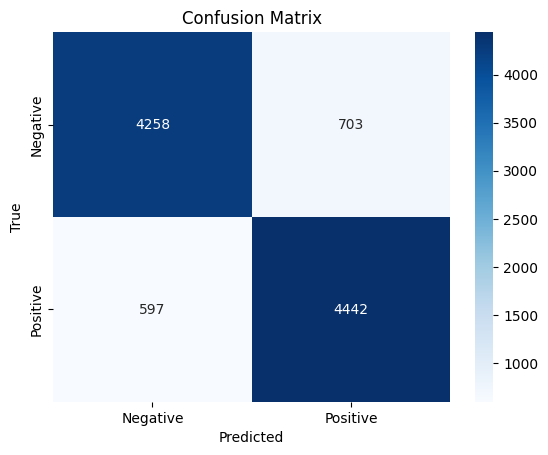

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc*100:.2f}% (Target ≥85%)")

y_pred = (model.predict(X_test) > 0.5).astype(int).flatten()
print(classification_report(y_test, y_pred, target_names=['Negative', 'Positive']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.show()

# Step 10: Graphs of Training Progress (Accuracy & Loss Curves)

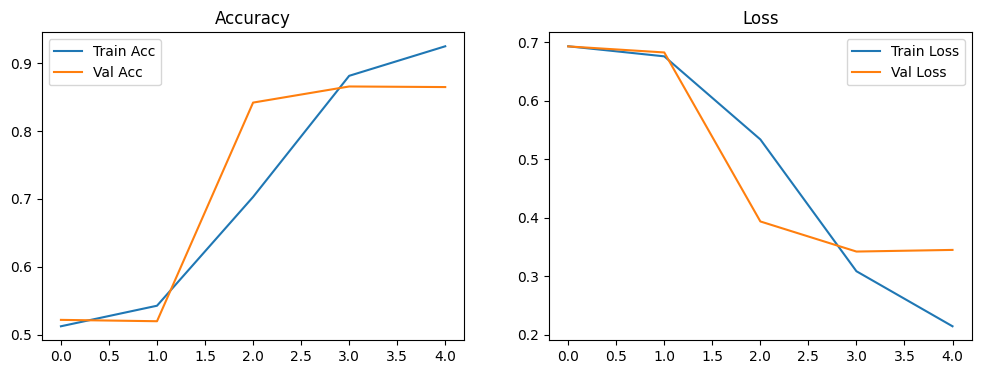

In [ ]:
if 'history' in locals():  # Only if we trained this session
    plt.figure(figsize=(12,4))

    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title('Accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title('Loss')
    plt.legend()

    plt.show()

# Step 11: Manual Test

In [ ]:
def predict_sentiment(text):
    cleaned = preprocess_text(text)
    seq = tokenizer.texts_to_sequences([cleaned])
    padded_seq = pad_sequences(seq, maxlen=max_length, padding='post', truncating='post')
    pred = model.predict(padded_seq)[0][0]
    return "Positive" if pred > 0.5 else "Negative", pred

# Test
print(predict_sentiment("This movie was an absolute delight! The pacing was perfect, and the chemistry between the lead actors felt incredibly genuine. I was hooked from the opening scene to the emotional finale. A true masterpiece that I’ll definitely watch again."))
print(predict_sentiment("I regret spending money on this. The plot was full of holes and the dialogue felt lazy and uninspired. It dragged on for way too long with zero character development. Honestly, it was a boring waste of two hours.."))

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step
('Positive', np.float32(0.9643466))
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step
('Negative', np.float32(0.025643302))


# The Final Demo (Need the .h5 and tokenizer)

In [ ]:
# -Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# --needed stuff
import os
import pickle
import re
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import load_model

# --paths
save_dir = '/content/drive/MyDrive/sentiment_project/'
model_path = os.path.join(save_dir, 'sentiment_model.h5')          # .h5 model
tokenizer_path = os.path.join(save_dir, 'tokenizer.pickle')        # tokenizer

# -file check
if not os.path.exists(model_path):
    print(f"ERROR: Model file not found at {model_path}")
    print("Make sure you have trained and saved the model earlier.")
    raise FileNotFoundError("Missing sentiment_model.h5")

if not os.path.exists(tokenizer_path):
    print(f"ERROR: Tokenizer file not found at {tokenizer_path}")
    raise FileNotFoundError("Missing tokenizer.pickle")

# -load
print("Loading your trained LSTM model and tokenizer from Google Drive...")
model = load_model(model_path)                                     # Loads .h5 file
with open(tokenizer_path, 'rb') as f:
    tokenizer = pickle.load(f)
print("Model and tokenizer loaded successfully! 🎉\n")

# -preprocessing/cleaning user input review
def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)          # Remove HTML tags
    text = re.sub(r'[^\w\s]', '', text)        # Remove punctuation
    try:
        import nltk
        from nltk.corpus import stopwords
        nltk.download('stopwords', quiet=True)
        stop_words = set(stopwords.words('english'))
        words = [w for w in text.split() if w not in stop_words]
    except:
        words = text.split()                   # Skip stopwords if NLTK fails
    return ' '.join(words)

# -predict function
def predict_sentiment(review_text):
    cleaned = preprocess_text(review_text)
    sequence = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(sequence, maxlen=200, padding='post', truncating='post')
    prediction = model.predict(padded, verbose=0)[0][0]
    sentiment = "Positive 😊" if prediction > 0.5 else "Negative 😠"
    confidence = round(prediction if prediction > 0.5 else 1 - prediction, 3)
    return sentiment, confidence

# -gui demo
print("="*60)
print("       MOVIE REVIEW SENTIMENT ANALYZER (LIVE DEMO)")
print("="*60)
print("Type any movie review and press Enter.")
print("The model will instantly predict Positive or Negative.")
print("Type 'quit' or 'exit' to stop.\n")

while True:
    try:
        user_review = input("Enter your movie review: ").strip()
    except (EOFError, KeyboardInterrupt):
        print("\n\nGoodbye!")
        break

    if user_review.lower() in ['quit', 'exit', 'q']:
        print("\nThank you for testing!")
        break

    if not user_review:
        print("Please type a review!\n")
        continue

    sentiment, confidence = predict_sentiment(user_review)
    print(f"→ Prediction: {sentiment}   (Confidence: {confidence})")
    print("-" * 60 + "\n")